## Phase 2 : Préparation des features

Cette phase suit la méthodologie **CRISP-DM** (Data Preparation).  
Elle produit deux datasets distincts :
- `df_features_ready.csv` — pipeline ML (filtré, transformé, enrichi)
- `df_original_ready.csv` — pipeline détection d'anomalies (valeurs brutes préservées)

## 1. Imports

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from sklearn.model_selection import TimeSeriesSplit

## 2. Chargement du dataset fusionné

Le fichier `cpu_full_dataset.csv` est produit par la phase 1 (fusion de 5 serveurs AWS CloudWatch).

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from sklearn.model_selection import TimeSeriesSplit

# ── Localisation du projet ───────────────────────────────────────────────
try:
    DOSSIER_PROJET = os.path.dirname(os.path.abspath(__file__))
except NameError:
    DOSSIER_PROJET = os.getcwd()

CSV_PATH = os.path.join(DOSSIER_PROJET, "cpu_full_dataset.csv")

# Si introuvable dans le dossier courant → recherche automatique
if not os.path.exists(CSV_PATH):
    import glob
    home = os.path.expanduser('~')
    matches = glob.glob(os.path.join(home, '**', 'cpu_full_dataset.csv'), recursive=True)
    if matches:
        DOSSIER_PROJET = os.path.dirname(matches[0])
        CSV_PATH = matches[0]
        print(f"CSV trouvé automatiquement : {DOSSIER_PROJET}")
    else:
        raise FileNotFoundError(
            "cpu_full_dataset.csv introuvable.\n"
            "Vérifie que phase1_data_exploration.ipynb a bien été exécuté "
            "et que le CSV est dans le même dossier que ce notebook."
        )

os.chdir(DOSSIER_PROJET)
print(f"✓ Dossier projet : {os.getcwd()}")

# ── Chargement ────────────────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(['serveur_id', 'timestamp']).reset_index(drop=True)

print(f"✓ Dataset chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"  Période : {df['timestamp'].min()} → {df['timestamp'].max()}")
print(f"  Serveurs : {sorted(df['serveur_id'].unique())}")
df.head()

CSV trouvé automatiquement : C:\Users\21624\Desktop\dataset pfe
✓ Dossier projet : C:\Users\21624\Desktop\dataset pfe
✓ Dataset chargé : 20160 lignes × 3 colonnes
  Période : 2014-02-14 14:27:00 → 2014-04-24 00:09:00
  Serveurs : ['24ae8d', '53ea38', '5f5533', '77c1ca', '825cc2']


,timestamp,value,serveur_id
0,2014-02-14 14:30:00,0.132,24ae8d
1,2014-02-14 14:35:00,0.134,24ae8d
2,2014-02-14 14:40:00,0.134,24ae8d
3,2014-02-14 14:45:00,0.134,24ae8d
4,2014-02-14 14:50:00,0.134,24ae8d


## 3. Séparation en deux pipelines

| Pipeline | Dataset | Usage | Traitement |
|---|---|---|---|
| ML | `df_features` | Prédiction | Filtré Hampel + log-transform |
| Anomalies | `df_original` | Détection | Valeurs brutes préservées |

Séparer les pipelines évite que le nettoyage masque les anomalies réelles.

In [5]:
df_features = df.copy()
df_original  = df.copy()
print("✓ Double pipeline créé")

✓ Double pipeline créé


## 4. Validation de l'isolement par serveur

Chaque serveur est traité indépendamment pour garantir la cohérence des features temporelles (lags, rolling windows).

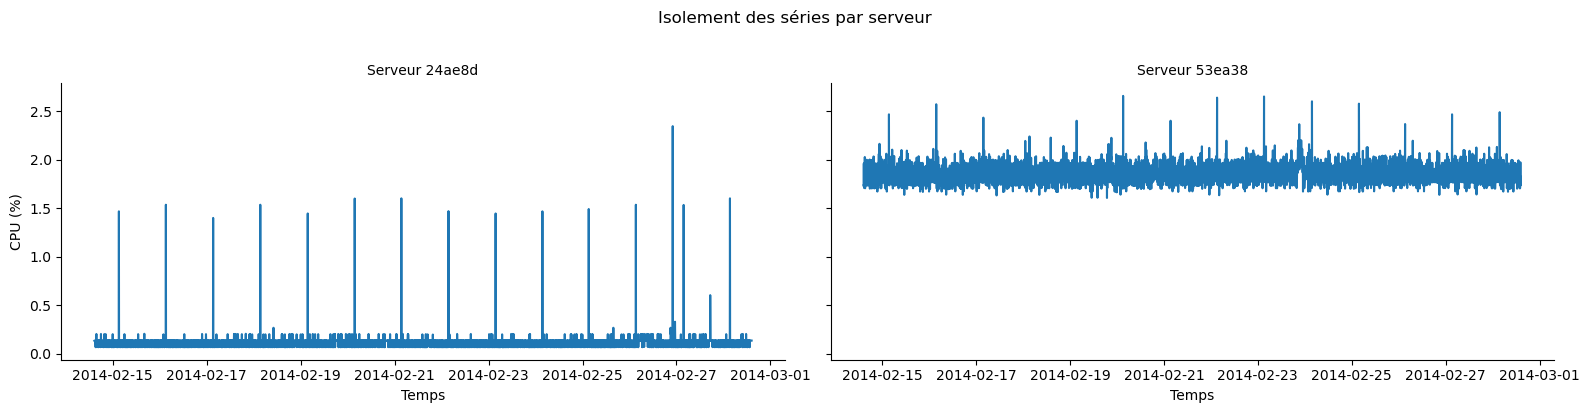

In [6]:
servers_plot = df_features['serveur_id'].unique()[:2]
df_plot = df_features[df_features['serveur_id'].isin(servers_plot)]

g = sns.FacetGrid(df_plot, col='serveur_id', height=4, aspect=2)
g.map(plt.plot, 'timestamp', 'value')
g.set_titles("Serveur {col_name}")
g.set_axis_labels("Temps", "CPU (%)")
plt.suptitle("Isolement des séries par serveur", y=1.02)
plt.tight_layout()
plt.show()

---
## Partie A — Pipeline ML (`df_features`)

### 5. Filtre de Hampel — détection et correction des outliers

Le filtre Hampel détecte les valeurs aberrantes en comparant chaque point à la médiane locale.  
Les outliers sont remplacés par la médiane (fenêtre de 5 observations, seuil 3σ).  
**Appliqué uniquement sur `df_features`** pour ne pas altérer les anomalies réelles dans `df_original`.

In [7]:
def hampel_filter(series, window_size=5, n_sigmas=3):
    """
    Détecte et corrige les outliers par la médiane locale (filtre de Hampel).
    Retourne une nouvelle série — pas de modification en place.
    """
    s = series.copy()  # évite SettingWithCopyWarning
    median    = s.rolling(window_size, center=True, min_periods=1).median()
    diff      = np.abs(s - median)
    mad       = diff.rolling(window_size, center=True, min_periods=1).median()
    threshold = n_sigmas * mad
    outliers  = diff > threshold
    s[outliers] = median[outliers]
    n_corrected = outliers.sum()
    return s, n_corrected

# Application par serveur
total_corrected = 0
df_features['value_filtered'] = df_features['value'].copy()

for srv in df_features['serveur_id'].unique():
    mask = df_features['serveur_id'] == srv
    filtered, n = hampel_filter(df_features.loc[mask, 'value'])
    df_features.loc[mask, 'value_filtered'] = filtered
    total_corrected += n
    print(f"  Serveur {srv} : {n} outliers corrigés")

print(f"\n✓ Total outliers corrigés : {total_corrected}")

  Serveur 24ae8d : 1152 outliers corrigés
  Serveur 53ea38 : 835 outliers corrigés
  Serveur 5f5533 : 602 outliers corrigés
  Serveur 77c1ca : 1156 outliers corrigés
  Serveur 825cc2 : 546 outliers corrigés

✓ Total outliers corrigés : 4291


### 6. Transformation logarithmique

`log1p(x)` stabilise la variance et réduit l'impact des pics extrêmes.  
Appliquée sur `value_filtered` (après Hampel).

In [8]:
df_features['value_log'] = np.log1p(df_features['value_filtered'])
print(f"✓ value_log créé | min={df_features['value_log'].min():.4f}, max={df_features['value_log'].max():.4f}")

✓ value_log créé | min=0.0620, max=4.6135


### 7. Moyennes mobiles (Rolling Mean)

Capturent la tendance locale.  
- `moyenne_mobile_5`  : tendance court terme (25 min)  
- `rolling_mean_10` : tendance moyen terme (50 min)

In [9]:
df_features['moyenne_mobile_5'] = (
    df_features.groupby('serveur_id')['value_log']
    .transform(lambda x: x.rolling(5, min_periods=1).mean())
)
df_features['rolling_mean_10'] = (
    df_features.groupby('serveur_id')['value_log']
    .transform(lambda x: x.rolling(10, min_periods=1).mean())
)
print("✓ moyenne_mobile_5, rolling_mean_10 créés")

✓ moyenne_mobile_5, rolling_mean_10 créés


**Visualisation — Lissage et tendance**

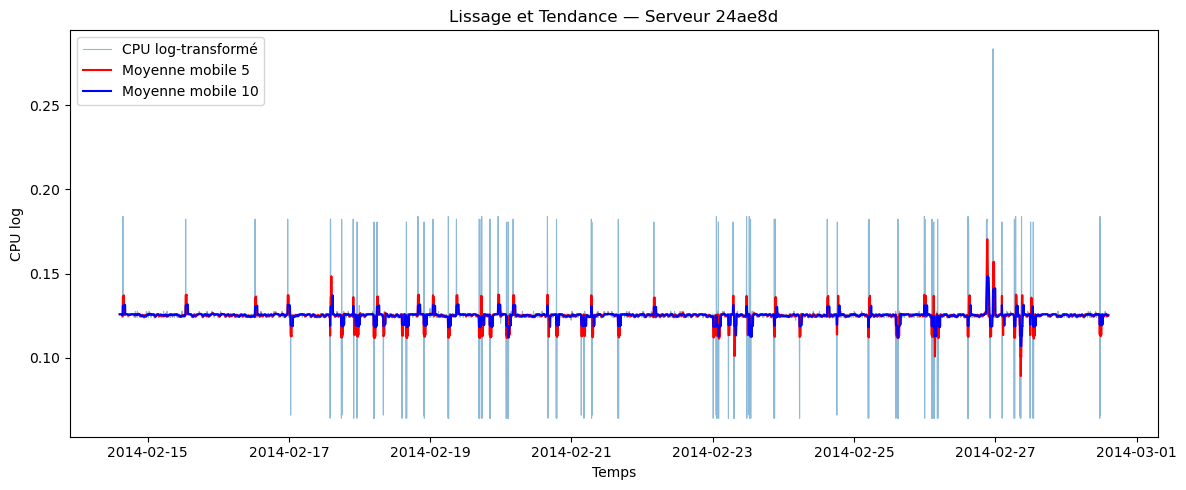

In [10]:
server_id = df_features['serveur_id'].unique()[0]
df_server = df_features[df_features['serveur_id'] == server_id]

plt.figure(figsize=(12, 5))
plt.plot(df_server['timestamp'], df_server['value_log'],
         label='CPU log-transformé', alpha=0.5, linewidth=0.8)
plt.plot(df_server['timestamp'], df_server['moyenne_mobile_5'],
         label='Moyenne mobile 5', color='red', linewidth=1.5)
plt.plot(df_server['timestamp'], df_server['rolling_mean_10'],
         label='Moyenne mobile 10', color='blue', linewidth=1.5)
plt.title(f"Lissage et Tendance — Serveur {server_id}")
plt.xlabel("Temps")
plt.ylabel("CPU log")
plt.legend()
plt.tight_layout()
plt.show()

> **Interprétation :** La moyenne mobile élimine les micro-fluctuations et révèle la tendance générale. Une fenêtre de 5 (25 min) suit les changements rapides ; une fenêtre de 10 (50 min) donne la tendance de fond.

### 8. Variable cible (Target)

`target = value_log(t+1)` — transforme le problème en **régression supervisée** :  
le modèle prédit la prochaine valeur CPU à partir des features actuelles.

In [11]:
df_features['target'] = (
    df_features.groupby('serveur_id')['value_log'].shift(-1)
)
print(f"✓ target créé | NaN attendus (dernière obs. par serveur) : {df_features['target'].isna().sum()}")

✓ target créé | NaN attendus (dernière obs. par serveur) : 5


### 9. Lag features

Les lags capturent la dépendance temporelle (autocorrélation).  
Chaque lag représente la valeur CPU à t-k instants passés.

In [12]:
for lag in [1, 2, 3, 5, 10]:
    df_features[f'lag_{lag}'] = (
        df_features.groupby('serveur_id')['value_log'].shift(lag)
    )
print("✓ lag_1, lag_2, lag_3, lag_5, lag_10 créés")
df_features[['value_log', 'lag_1', 'lag_2', 'lag_3', 'lag_5', 'lag_10']].head(8)

✓ lag_1, lag_2, lag_3, lag_5, lag_10 créés


,value_log,lag_1,lag_2,lag_3,lag_5,lag_10
0,0.125751,NaN,NaN,NaN,NaN,NaN
1,0.125751,0.125751,NaN,NaN,NaN,NaN
2,0.125751,0.125751,0.125751,NaN,NaN,NaN
3,0.125751,0.125751,0.125751,0.125751,NaN,NaN
4,0.125751,0.125751,0.125751,0.125751,NaN,NaN
5,0.125751,0.125751,0.125751,0.125751,0.125751,NaN
6,0.125751,0.125751,0.125751,0.125751,0.125751,NaN
7,0.125751,0.125751,0.125751,0.125751,0.125751,NaN


**Visualisation — Autocorrélation (lag_2 vs target)**

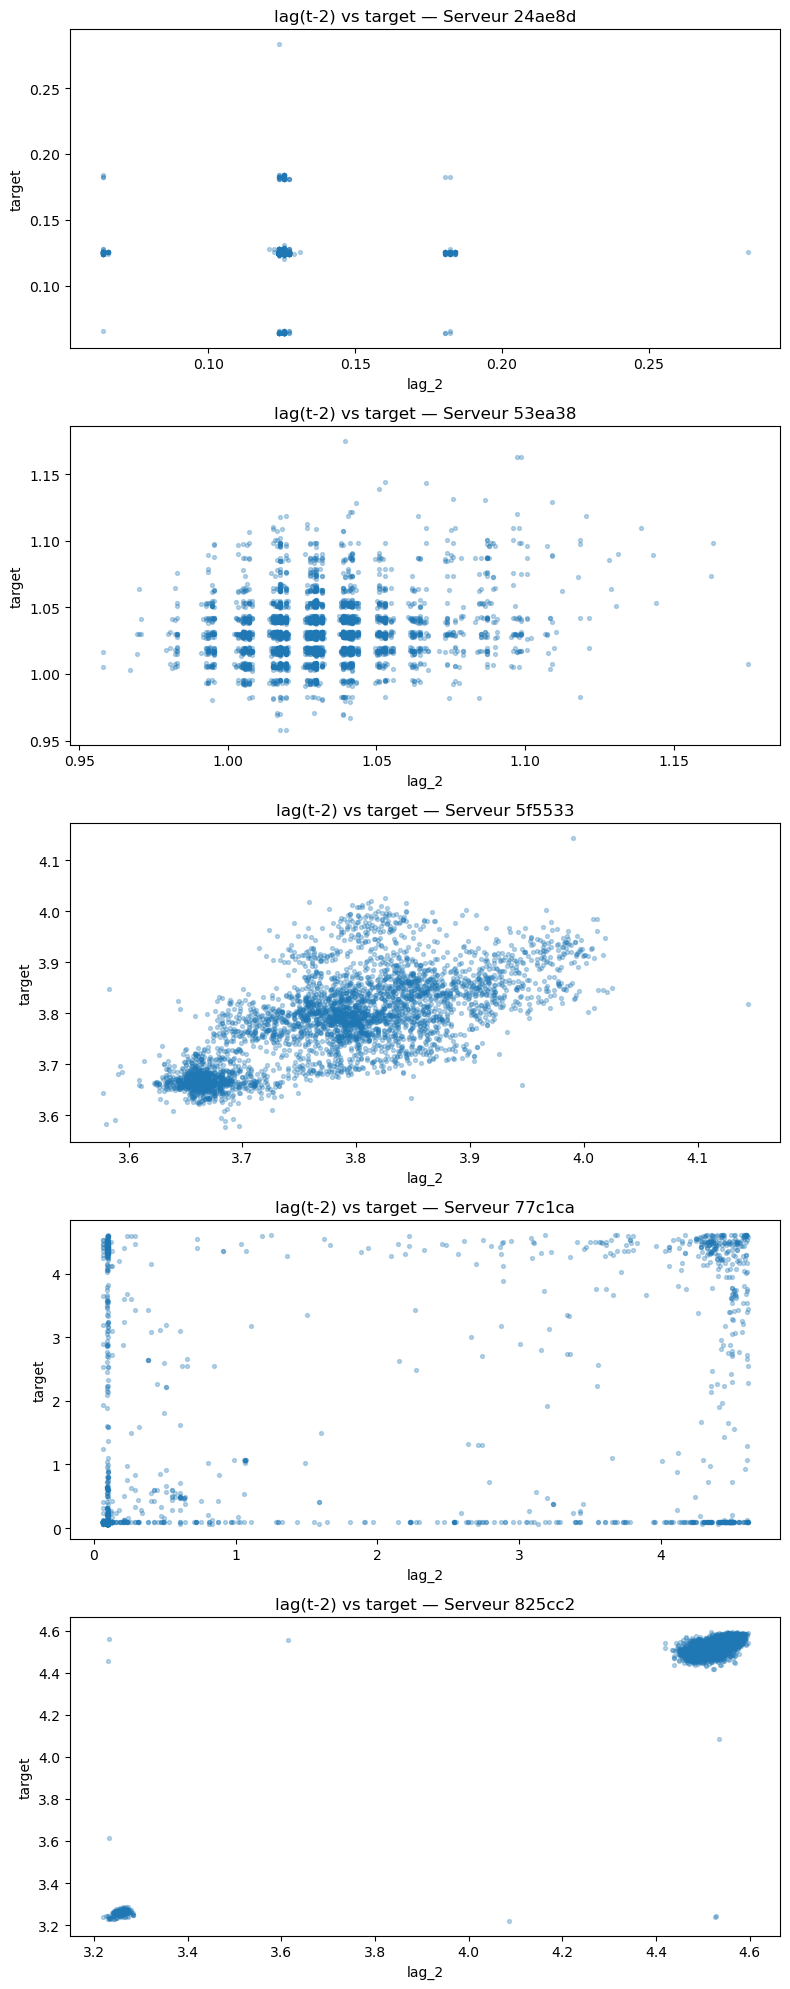

In [13]:
servers = df_features['serveur_id'].unique()
fig, axes = plt.subplots(len(servers), 1, figsize=(8, 4 * len(servers)), sharex=False)
if len(servers) == 1:
    axes = [axes]

for ax, srv in zip(axes, servers):
    df_s = df_features[df_features['serveur_id'] == srv].dropna(subset=['lag_2', 'target'])
    ax.scatter(df_s['lag_2'], df_s['target'], alpha=0.3, s=8)
    ax.set_title(f"lag(t-2) vs target — Serveur {srv}")
    ax.set_xlabel("lag_2")
    ax.set_ylabel("target")

plt.tight_layout()
plt.show()

> **Interprétation :** La corrélation positive entre lag_2 et target justifie l'utilisation de modèles supervisés. Plus le nuage est linéaire, plus la série est prévisible à partir de son passé.

### 10. Écart-type mobile (Volatilité)

Capture l'instabilité locale du CPU.  
- `rolling_std_5`  : volatilité court terme  
- `rolling_std_10` : volatilité moyen terme  
Un écart-type élevé indique un serveur sous charge variable.

In [14]:
df_features['rolling_std_5'] = (
    df_features.groupby('serveur_id')['value_log']
    .transform(lambda x: x.rolling(5, min_periods=1).std())
)
df_features['rolling_std_10'] = (
    df_features.groupby('serveur_id')['value_log']
    .transform(lambda x: x.rolling(10, min_periods=1).std())
)
print("✓ rolling_std_5, rolling_std_10 créés")

✓ rolling_std_5, rolling_std_10 créés


**Visualisation — Volatilité**

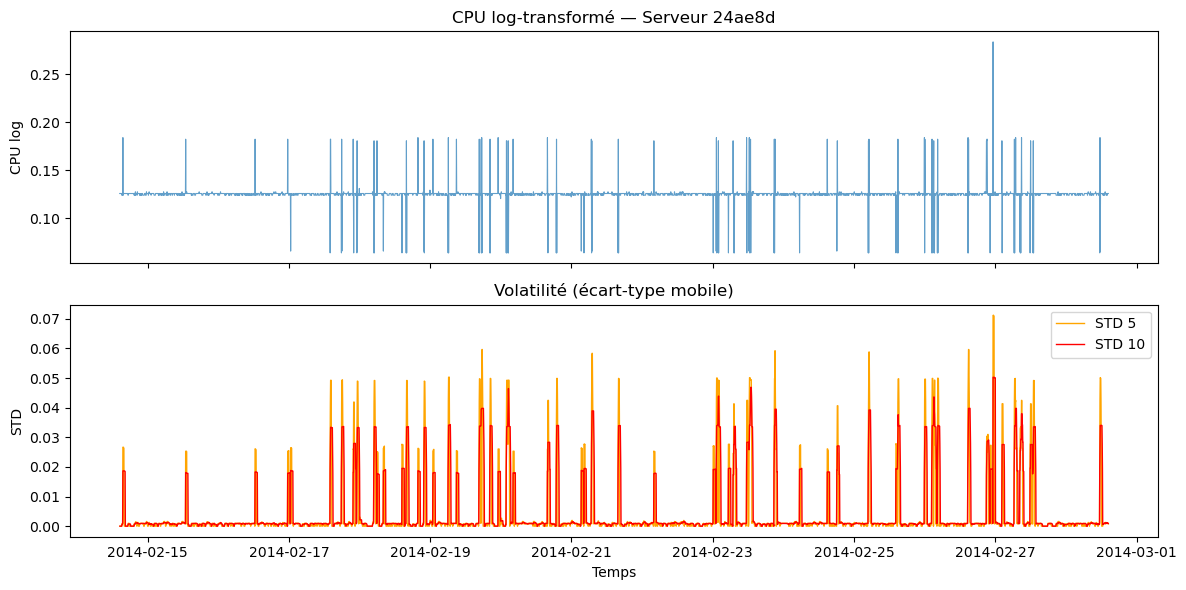

In [15]:
server_id = df_features['serveur_id'].unique()[0]
df_server  = df_features[df_features['serveur_id'] == server_id]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(df_server['timestamp'], df_server['value_log'],
             alpha=0.7, linewidth=0.8)
axes[0].set_title(f"CPU log-transformé — Serveur {server_id}")
axes[0].set_ylabel("CPU log")

axes[1].plot(df_server['timestamp'], df_server['rolling_std_5'],
             color='orange', label='STD 5', linewidth=1)
axes[1].plot(df_server['timestamp'], df_server['rolling_std_10'],
             color='red', label='STD 10', linewidth=1)
axes[1].set_title("Volatilité (écart-type mobile)")
axes[1].set_ylabel("STD")
axes[1].set_xlabel("Temps")
axes[1].legend()

plt.tight_layout()
plt.show()

> **Interprétation :** Les pics dans l'écart-type correspondent aux périodes d'instabilité du serveur — potentiellement associés à des anomalies ou des changements de charge brusques.

### 11. Différenciation

Capture les **changements instantanés** du CPU.  
`diff_1` = valeur(t) − valeur(t−1) : utile pour détecter les pics soudains.

In [16]:
df_features['diff_1'] = (
    df_features.groupby('serveur_id')['value_log'].diff(1)
)
df_features['diff_2'] = (
    df_features.groupby('serveur_id')['value_log'].diff(2)
)
print("✓ diff_1, diff_2 créés")

✓ diff_1, diff_2 créés


**Visualisation — Différenciation**

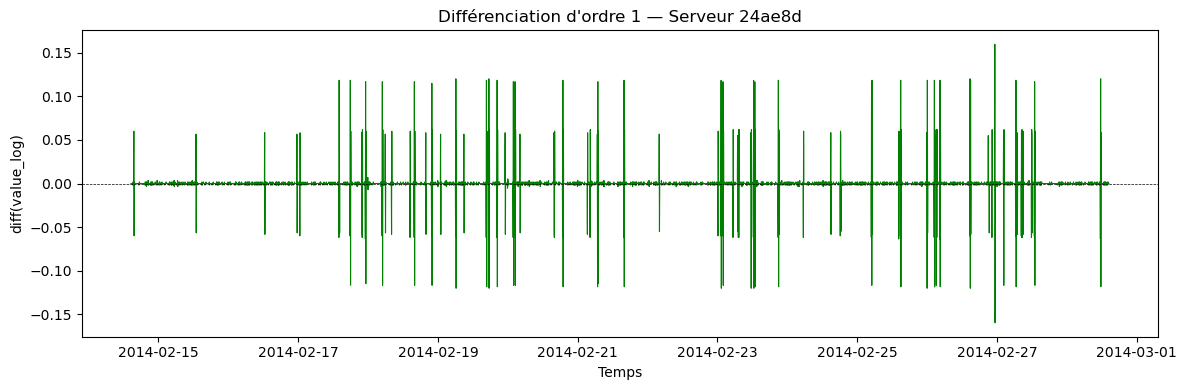

In [17]:
server_id = df_features['serveur_id'].unique()[0]
df_server  = df_features[df_features['serveur_id'] == server_id]

plt.figure(figsize=(12, 4))
plt.plot(df_server['timestamp'], df_server['diff_1'],
         color='green', linewidth=0.8)
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.title(f"Différenciation d'ordre 1 — Serveur {server_id}")
plt.xlabel("Temps")
plt.ylabel("diff(value_log)")
plt.tight_layout()
plt.show()

> **Interprétation :** Les écarts autour de zéro mettent en évidence les changements brusques de charge CPU. Une série de diff_1 qui oscille autour de 0 indique une série stationnaire en tendance.

### 12. Features temporelles + encodage cyclique

`hour` et `weekday` bruts ne sont pas directement exploitables par les modèles ML  
car ils sont **cycliques** (heure 23 est proche de heure 0, mais numériquement distants).  
L'encodage sin/cos résout ce problème.

| Feature | Période | Signification |
|---|---|---|
| `hour_sin`, `hour_cos` | 24h | Patterns journaliers |
| `weekday_sin`, `weekday_cos` | 7j | Patterns hebdomadaires |

In [18]:
# Extraction des features temporelles brutes
df_features['hour']    = df_features['timestamp'].dt.hour
df_features['weekday'] = df_features['timestamp'].dt.weekday

# Encodage cyclique — produit ici en phase 2, pas en phase 3
df_features['hour_sin']    = np.sin(2 * np.pi * df_features['hour']    / 24)
df_features['hour_cos']    = np.cos(2 * np.pi * df_features['hour']    / 24)
df_features['weekday_sin'] = np.sin(2 * np.pi * df_features['weekday'] / 7)
df_features['weekday_cos'] = np.cos(2 * np.pi * df_features['weekday'] / 7)

print("✓ hour, weekday, hour_sin, hour_cos, weekday_sin, weekday_cos créés")

✓ hour, weekday, hour_sin, hour_cos, weekday_sin, weekday_cos créés


**Visualisation — Patterns cycliques**

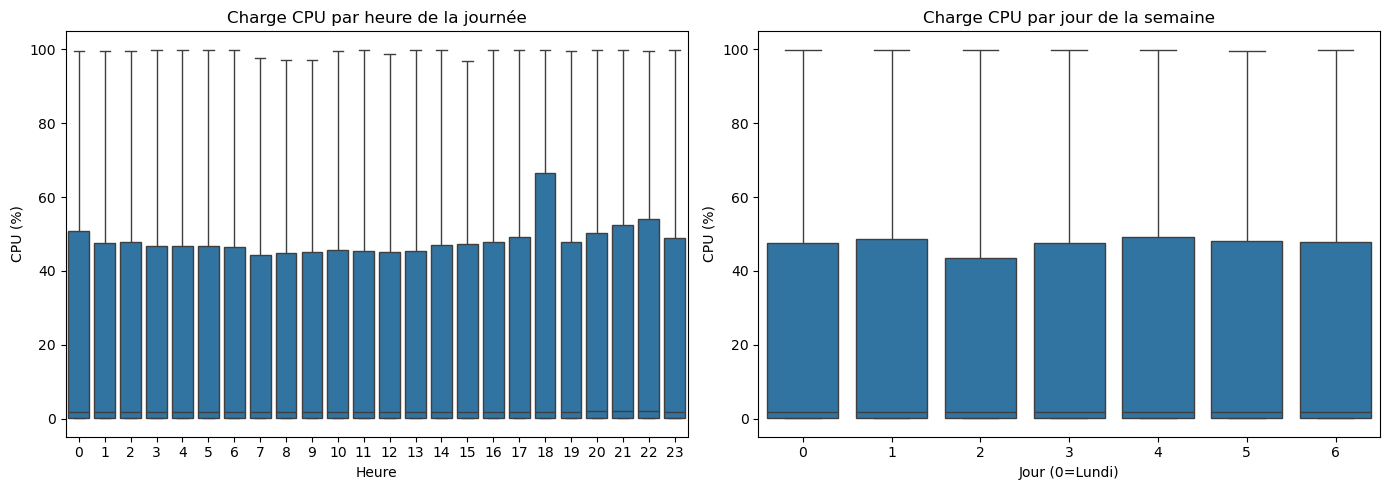

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='hour', y='value', data=df_features, ax=axes[0])
axes[0].set_title("Charge CPU par heure de la journée")
axes[0].set_xlabel("Heure")
axes[0].set_ylabel("CPU (%)")

sns.boxplot(x='weekday', y='value', data=df_features, ax=axes[1])
axes[1].set_title("Charge CPU par jour de la semaine")
axes[1].set_xlabel("Jour (0=Lundi)")
axes[1].set_ylabel("CPU (%)")

plt.tight_layout()
plt.show()

> **Interprétation :** Les boxplots révèlent des variations récurrentes selon l'heure et le jour. Ces patterns justifient l'ajout des features cycliques pour capturer la saisonnalité intra-journalière.

### 13. Récapitulatif des features créées

In [20]:
FEATURES_ML = [
    'lag_1', 'lag_2', 'lag_3', 'lag_5', 'lag_10',
    'moyenne_mobile_5', 'rolling_mean_10',
    'rolling_std_5', 'rolling_std_10',
    'diff_1', 'diff_2',
    'hour_sin', 'hour_cos',
    'weekday_sin', 'weekday_cos',
]

print(f"Nombre de features ML : {len(FEATURES_ML)}")
print("\nVérification présence dans df_features :")
for f in FEATURES_ML:
    status = "✓" if f in df_features.columns else "✗ MANQUANTE"
    print(f"  {status}  {f}")

Nombre de features ML : 15

Vérification présence dans df_features :
  ✓  lag_1
  ✓  lag_2
  ✓  lag_3
  ✓  lag_5
  ✓  lag_10
  ✓  moyenne_mobile_5
  ✓  rolling_mean_10
  ✓  rolling_std_5
  ✓  rolling_std_10
  ✓  diff_1
  ✓  diff_2
  ✓  hour_sin
  ✓  hour_cos
  ✓  weekday_sin
  ✓  weekday_cos


### 14. Nettoyage final

Suppression des NaN introduits par les lags et rolling windows.  
Ces NaN sont inévitables pour les premières observations de chaque serveur.

In [21]:
n_avant = len(df_features)
df_features = df_features.dropna(subset=FEATURES_ML + ['target']).reset_index(drop=True)
n_apres  = len(df_features)
print(f"✓ Lignes supprimées (NaN) : {n_avant - n_apres} ({(n_avant - n_apres)/n_avant*100:.1f}%)")
print(f"✓ Dataset final : {df_features.shape[0]} lignes × {df_features.shape[1]} colonnes")

✓ Lignes supprimées (NaN) : 55 (0.3%)
✓ Dataset final : 20105 lignes × 23 colonnes


---
## Partie B — Pipeline Détection d'anomalies (`df_original`)

Le pipeline anomalies utilise les **valeurs brutes** (`value`, non filtrées Hampel)  
pour ne pas masquer les comportements anormaux à détecter en phase 4.

In [22]:
df_original = df_original.reset_index(drop=True)

df_original['diff_1'] = (
    df_original.groupby('serveur_id')['value'].diff()
)
df_original['rolling_std_5'] = (
    df_original.groupby('serveur_id')['value']
    .transform(lambda x: x.rolling(5, min_periods=1).std())
)
print("✓ diff_1, rolling_std_5 ajoutés à df_original")
df_original.head()

✓ diff_1, rolling_std_5 ajoutés à df_original


,timestamp,value,serveur_id,diff_1,rolling_std_5
0,2014-02-14 14:30:00,0.132,24ae8d,NaN,NaN
1,2014-02-14 14:35:00,0.134,24ae8d,0.002,0.001414
2,2014-02-14 14:40:00,0.134,24ae8d,0.000,0.001155
3,2014-02-14 14:45:00,0.134,24ae8d,0.000,0.001000
4,2014-02-14 14:50:00,0.134,24ae8d,0.000,0.000894


### 15. Détection préliminaire d'anomalies (règle 3-sigma)

Utilisée comme **baseline** en phase 4.  
`anomaly = 1` si la variabilité locale dépasse la moyenne + 3 écarts-types.

In [23]:
threshold = (
    df_original['rolling_std_5'].mean()
    + 3 * df_original['rolling_std_5'].std()
)
df_original['anomaly'] = (df_original['rolling_std_5'] > threshold).astype(int)

n_anomalies = df_original['anomaly'].sum()
print(f"✓ Seuil 3-sigma : {threshold:.4f}")
print(f"✓ Anomalies détectées : {n_anomalies} ({n_anomalies/len(df_original)*100:.2f}%)")

✓ Seuil 3-sigma : 24.4089
✓ Anomalies détectées : 646 (3.20%)


---
## Partie C — Validation temporelle (TimeSeriesSplit)

`TimeSeriesSplit` garantit que le modèle est toujours évalué sur des données **futures** par rapport à l'entraînement.  
Cela évite tout data leakage — condition essentielle pour les séries temporelles.

In [24]:
X = df_features[FEATURES_ML]
y = df_features['target']

N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

print(f"TimeSeriesSplit — {N_SPLITS} splits chronologiques")
print(f"Dataset total : {len(X)} observations\n")

for i, (train_idx, test_idx) in enumerate(tscv.split(X)):
    print(f"Split {i+1} | Train: {len(train_idx):6d} obs | Test: {len(test_idx):5d} obs "
          f"| Train [{train_idx[0]}→{train_idx[-1]}] | Test [{test_idx[0]}→{test_idx[-1]}]")

TimeSeriesSplit — 5 splits chronologiques
Dataset total : 20105 observations

Split 1 | Train:   3355 obs | Test:  3350 obs | Train [0→3354] | Test [3355→6704]
Split 2 | Train:   6705 obs | Test:  3350 obs | Train [0→6704] | Test [6705→10054]
Split 3 | Train:  10055 obs | Test:  3350 obs | Train [0→10054] | Test [10055→13404]
Split 4 | Train:  13405 obs | Test:  3350 obs | Train [0→13404] | Test [13405→16754]
Split 5 | Train:  16755 obs | Test:  3350 obs | Train [0→16754] | Test [16755→20104]


**Visualisation — Découpage temporel des splits**

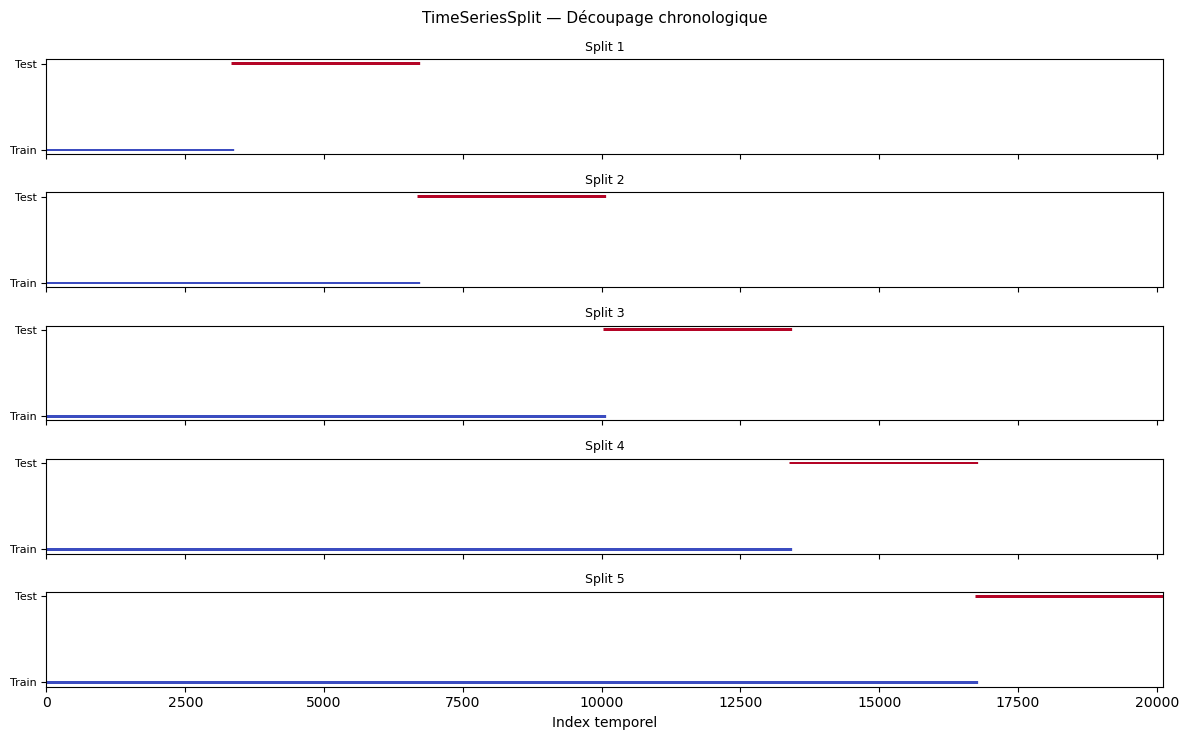

In [25]:
fig, axes = plt.subplots(N_SPLITS, 1, figsize=(12, N_SPLITS * 1.5), sharex=True)

for i, (train_idx, test_idx) in enumerate(tscv.split(X)):
    visual = np.full(len(X), np.nan)
    visual[train_idx] = 0
    visual[test_idx]  = 1
    axes[i].scatter(range(len(X)), visual, c=visual, cmap='coolwarm', s=4, marker='|')
    axes[i].set_yticks([0, 1])
    axes[i].set_yticklabels(['Train', 'Test'], fontsize=8)
    axes[i].set_title(f"Split {i+1}", fontsize=9)
    axes[i].set_xlim(0, len(X))

plt.suptitle("TimeSeriesSplit — Découpage chronologique", fontsize=11)
plt.xlabel("Index temporel")
plt.tight_layout()
plt.show()

> **Interprétation :** Le jeu d'entraînement grandit à chaque split. Le test contient toujours des données **futures** par rapport au train — aucun data leakage.

---
## Partie D — Test de stationnarité (Dickey-Fuller augmenté)

Le test ADF est appliqué **par serveur** pour respecter l'indépendance des séries.  
Tester toutes les séries mélangées produirait un résultat biaisé.

In [26]:
print("=" * 60)
print("  TEST ADF — STATIONNARITÉ PAR SERVEUR")
print("=" * 60)

for srv in sorted(df_features['serveur_id'].unique()):
    serie = df_features.loc[df_features['serveur_id'] == srv, 'value_log'].dropna()
    result = adfuller(serie)
    stationnaire = result[1] < 0.05
    status = "✓ Stationnaire" if stationnaire else "✗ Non stationnaire"
    print(f"\nServeur {srv}")
    print(f"  ADF Statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.4f}")
    print(f"  → {status}")

  TEST ADF — STATIONNARITÉ PAR SERVEUR

Serveur 24ae8d
  ADF Statistic : -11.9695
  p-value       : 0.0000
  → ✓ Stationnaire

Serveur 53ea38
  ADF Statistic : -9.9403
  p-value       : 0.0000
  → ✓ Stationnaire

Serveur 5f5533
  ADF Statistic : -1.0083
  p-value       : 0.7502
  → ✗ Non stationnaire

Serveur 77c1ca
  ADF Statistic : -10.9579
  p-value       : 0.0000
  → ✓ Stationnaire

Serveur 825cc2
  ADF Statistic : -4.3258
  p-value       : 0.0004
  → ✓ Stationnaire


### Test ADF après différenciation

Si certaines séries sont non stationnaires en brut, la différenciation (`diff_1`) les stabilise.

In [27]:
print("=" * 60)
print("  TEST ADF — SÉRIE DIFFÉRENCIÉE PAR SERVEUR")
print("=" * 60)

for srv in sorted(df_features['serveur_id'].unique()):
    serie_diff = df_features.loc[df_features['serveur_id'] == srv, 'diff_1'].dropna()
    result = adfuller(serie_diff)
    stationnaire = result[1] < 0.05
    status = "✓ Stationnaire après différenciation" if stationnaire else "✗ Toujours non stationnaire"
    print(f"\nServeur {srv}")
    print(f"  ADF Statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.4f}")
    print(f"  → {status}")

  TEST ADF — SÉRIE DIFFÉRENCIÉE PAR SERVEUR

Serveur 24ae8d
  ADF Statistic : -22.2415
  p-value       : 0.0000
  → ✓ Stationnaire après différenciation

Serveur 53ea38
  ADF Statistic : -16.3188
  p-value       : 0.0000
  → ✓ Stationnaire après différenciation

Serveur 5f5533
  ADF Statistic : -18.1688
  p-value       : 0.0000
  → ✓ Stationnaire après différenciation

Serveur 77c1ca
  ADF Statistic : -17.3658
  p-value       : 0.0000
  → ✓ Stationnaire après différenciation

Serveur 825cc2
  ADF Statistic : -17.9146
  p-value       : 0.0000
  → ✓ Stationnaire après différenciation


**Interprétation :** Le test de Dickey-Fuller confirme que la transformation logarithmique + différenciation  
rend les séries stationnaires. Cela valide l'utilisation des features `diff_1`, `diff_2` dans les modèles ML  
et justifie le paramètre `d=1` si des modèles ARIMA devaient être utilisés.

---
## Partie E — Sauvegarde des datasets

Les deux CSV produits ici alimentent les phases suivantes :
- `df_features_ready.csv` → phase 3 (prédiction ML)
- `df_original_ready.csv` → phase 4 (détection d'anomalies)

In [28]:
features_path  = os.path.join(DOSSIER_PROJET, "df_features_ready.csv")
original_path  = os.path.join(DOSSIER_PROJET, "df_original_ready.csv")

df_features.to_csv(features_path,  index=False)
df_original.to_csv(original_path,  index=False)

print(f"✓ df_features_ready.csv sauvegardé → {df_features.shape}")
print(f"✓ df_original_ready.csv sauvegardé → {df_original.shape}")
print(f"\nFeatures présentes dans df_features_ready.csv :")
print([c for c in df_features.columns])

✓ df_features_ready.csv sauvegardé → (20105, 23)
✓ df_original_ready.csv sauvegardé → (20160, 6)

Features présentes dans df_features_ready.csv :
['timestamp', 'value', 'serveur_id', 'value_filtered', 'value_log', 'moyenne_mobile_5', 'rolling_mean_10', 'target', 'lag_1', 'lag_2', 'lag_3', 'lag_5', 'lag_10', 'rolling_std_5', 'rolling_std_10', 'diff_1', 'diff_2', 'hour', 'weekday', 'hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos']
